In [22]:
from typing import TypedDict

class Mystate(TypedDict):
    messages:str

In [81]:
def function1(input):
    return input+ " from first function"
def function2(input):
    return input+" from second function"
def function3(input):
   pass

In [83]:
function1("lucy")

'lucy from first function'

In [84]:
function2("jerry")

'jerry from second function'

In [85]:
from langgraph.graph import StateGraph

In [86]:
workflow1=StateGraph(str)

In [87]:
workflow1.add_node("fun1",function1)

In [88]:
workflow1.add_node("fun2",function2)

In [89]:
workflow1.add_edge("fun1","fun2")

In [90]:
workflow1.set_entry_point("fun1")

In [91]:
workflow1.set_finish_point("fun2")

In [92]:
app=workflow1.compile()

In [93]:
from IPython.display import Image,display

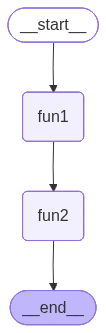

In [94]:
display(Image(app.get_graph().draw_mermaid_png()))

In [95]:
app.invoke("hi from lucy")

'hi from lucy from first function from second function'

Output from seprate nodes

In [96]:
for opt in app.stream("hi this is sunny"):
    for key,value in opt.items():
        print(f"here is my output from {key}")
        print("______")
        print(value)
        print("\n")

here is my output from fun1
______
hi this is sunny from first function


here is my output from fun2
______
hi this is sunny from first function from second function




In [97]:
from langchain_google_genai import ChatGoogleGenerativeAI
model=ChatGoogleGenerativeAI(model='gemini-2.0-flash')

In [98]:
def llm(input):
    output=model.invoke(input).content
    return output

In [99]:
def token_counter(input):
    tokens=input.split()
    token_number=len(tokens)
    return f"Total number of tokens in generated answer is {token_number}"

In [101]:
workflow2=StateGraph(str)

In [102]:
workflow2.add_node("my llm",llm)

In [103]:
workflow2.add_node("llm output counter",token_counter)

In [104]:
workflow2.add_edge("my llm","llm output counter")

In [105]:
workflow2.set_entry_point("my llm")

In [106]:
workflow2.set_finish_point("llm output counter")

In [107]:
app=workflow2.compile()

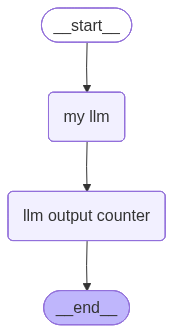

In [108]:
display(Image(app.get_graph().draw_mermaid_png()))

In [110]:
app.invoke("tell me about indian cricket")

'Total number of tokens in generated answer is651'

In [111]:
app.invoke("tell me about the tata enterprise in very detail")

'Total number of tokens in generated answer is1293'

In [112]:
for opt in app.stream("tell me about the tata enterprise in very detail"):
    for key,value in opt.items():
        print(f"here is my output from {key}")
        print("______")
        print(value)
        print("\n")

here is my output from my llm
______
Okay, let's delve into the Tata Group, a sprawling, multi-faceted conglomerate that's deeply ingrained in India's history and economy.  We'll cover its history, structure, key companies, values, impact, and some of the challenges it faces.

**I. Historical Roots and Evolution:**

*   **Founding (1868):**  The Tata Group was founded by Jamsetji Nusserwanji Tata in 1868 as a trading company.  He was a visionary entrepreneur who believed in India's potential and wanted to contribute to its industrial development.
*   **Key Early Ventures:**
    *   **Textiles:** The Central India Spinning, Weaving, and Manufacturing Company (later Empress Mills) was one of the first major ventures, establishing Tata's presence in the textile industry.
    *   **Taj Mahal Hotel (1903):**  A landmark project, the Taj Mahal Palace Hotel in Mumbai, was a response to racial discrimination that Jamsetji Tata experienced in British-owned hotels. It symbolized Indian pride and